C:\Users\rozsa\AppData\Local\Temp\ipykernel_18544\2930481150.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=robustness_df, x='Scenario', y='F1-Score', palette='Reds_r')


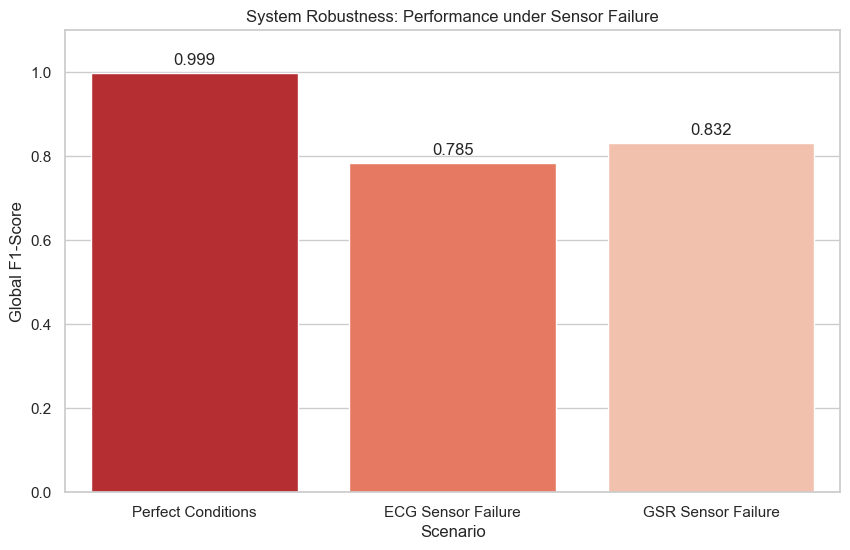

Results saved to robustness_modality_dropout.png
             Scenario  F1-Score
0  Perfect Conditions  0.999212
1  ECG Sensor Failure  0.784574
2  GSR Sensor Failure  0.831827


In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score

# Load data sand saved model
df = pd.read_csv('wesad_final_normalized_features.csv')
with open('final_fusion_model.pkl', 'rb') as f:
    model = pickle.load(f)

# Define feature groups
ecg_cols = [c for c in df.columns if 'HRV' in c or 'ECG_Rate' in c]
gsr_cols = [c for c in df.columns if 'SCR' in c or 'EDA' in c]
fusion_cols = ecg_cols + gsr_cols

# ground truth
y_true = df['label'].map({1: 0, 2: 1})
X_original = df[fusion_cols].copy()

# Failing scenarios to test robustness
scenarios = {
    'Perfect Conditions': X_original.copy(),
    'ECG Sensor Failure': X_original.copy(),
    'GSR Sensor Failure': X_original.copy()
}

# Simulate failures: zeroing out the features
scenarios['ECG Sensor Failure'][ecg_cols] = 0
scenarios['GSR Sensor Failure'][gsr_cols] = 0

# Run robustness tests
robustness_results = []

for name, X_test in scenarios.items():
    preds = model.predict(X_test)
    f1 = f1_score(y_true, preds)
    robustness_results.append({'Scenario': name, 'F1-Score': f1})

robustness_df = pd.DataFrame(robustness_results)

# Visualization of Performance Decay
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
ax = sns.barplot(data=robustness_df, x='Scenario', y='F1-Score', palette='Reds_r')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 9), 
                textcoords='offset points')

plt.title('System Robustness: Performance under Sensor Failure')
plt.ylim(0, 1.1)
plt.ylabel('Global F1-Score')
plt.savefig('robustness_modality_dropout.png')
plt.show()

print("Results saved to robustness_modality_dropout.png")
print(robustness_df)